In [167]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from siriuspy.clientarch import Time, PVDataSet

GMTM3 = - 3.0 * 3600.0

In [168]:
pvs = ['SI-Glob:DI-Tune-H:TuneFrac-Mon', 'SI-Glob:DI-Tune-V:TuneFrac-Mon']

pvdata = PVDataSet(pvs)

# pvdata.time_start = Time(2026, 7, 17, 6, 0)
# pvdata.time_stop = Time(2026, 7, 17, 8, 20)

h = 14
pvdata.time_start = Time(2026, 7, 17, h, 0)
pvdata.time_stop = Time(2026, 7, 17, h+1, 0)

pvdata.query_timeout = 20.0
pvdata.update()

871 87.10000000000001


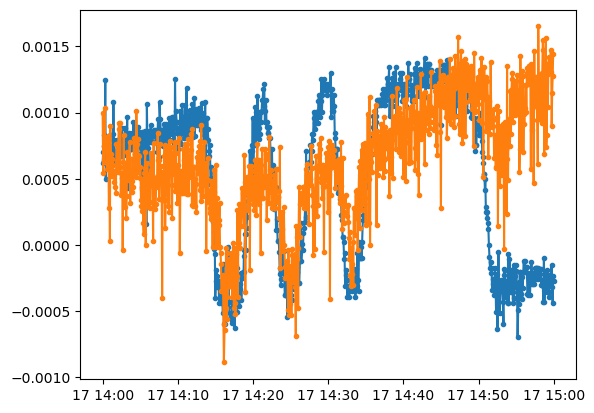

In [169]:
t = (pvdata[pvs[0]].timestamp + GMTM3).astype('datetime64[s]')
v = pvdata[pvs[0]].value
xfar = np.linspace(0, 8, len(t))
yfar = np.sin(2*np.pi*0.09*xfar - np.pi/3)*0.0001
xfinal = v-np.mean(v)+yfar+0.0005

ty = (pvdata[pvs[1]].timestamp + GMTM3).astype('datetime64[s]')
vy = pvdata[pvs[1]].value
xfar = np.linspace(0, 8, len(ty))
yfar = -np.sin(2*np.pi*0.07*xfar)*0.0005
yfinal = vy-np.mean(vy)+yfar+0.0005+0.0001*xfar

step = 30
plt.plot(t[::step], xfinal[::step], '.-')
plt.plot(ty[::step], yfinal[::step], '.-')

tosavey = yfinal[::step]
tosavex = xfinal[::step]
leng = min(len(tosavex), len(tosavey))
tosavex = tosavex[:leng]
tosavey = tosavey[:leng]
print(leng, leng * 0.1)

In [170]:
fpath = '/home/vitor/repos/dev-packages/siriuspy/siriuspy/opticscorr/'
np.save(fpath+'tunex_noise.npy', tosavex)
np.save(fpath+'tuney_noise.npy', tosavey)

In [171]:
import numpy as np

import pyaccel as pa
from pymodels import si

from apsuite.optics_analysis.tune_correction import TuneCorr
from siriuspy.opticscorr.csdev import Const

_quadrupole = pa.elements.quadrupole


class A:
    """."""
    def __init__(self):
        """."""
        self._corr_method = Const.CorrMeth.Proportional
        self._corr_group = Const.CorrGroup.TwoKnobs
        self._psfams = Const.SI_QFAMS_TUNECORR
        self._ref_tunex = 0.16
        self._ref_tuney = 0.22

        # SIMULATION ##########################################################
        _model = si.create_accelerator()
        self.SIMQUAD_LENG = 0.1

        _mia = pa.lattice.find_indices(_model, 'fam_name', 'mia')[-1]
        _mib = pa.lattice.find_indices(_model, 'fam_name', 'mib')[2]

        self._sim_quad_indices = [_mib, _mia]

        for i, idx in enumerate(self._sim_quad_indices):
            _model.insert(idx+i,
                _quadrupole(f'SimID_{i}', self.SIMQUAD_LENG, 0.0))
            self._sim_quad_indices[i] = idx + i

        self._sim_tunecorr = TuneCorr(_model, 'SI')
        self._sim_tunecorr.method = 0 \
            if self._corr_method == Const.CorrMeth.Proportional \
            else 1
        self._sim_tunecorr.grouping = self._corr_group
        self._sim_tunecorr.correct_parameters(
            [49+self._ref_tunex, 14+self._ref_tuney])
        self._psfam_refkl = {
            fam: kl for fam, kl in zip(  # ruff:ignore[zip-without-explicit-strict]
                self._psfams,
                self._sim_tunecorr.get_kl(self._sim_tunecorr.model)
            )
        }

    @property
    def model(self):
        """."""
        return self._sim_tunecorr.model

    def get_tunes(self):
        """."""
        _ed = pa.optics.calc_edwards_teng(self._sim_tunecorr.model)[0]
        return np.array([_ed.mu1[-1]/2/np.pi-49, _ed.mu2[-1]/2/np.pi-14])


a = A()

In [172]:
for _, idx in enumerate(a._sim_quad_indices):
    print(a.model[idx])

fam_name   : SimID_0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.1 m
nr_steps   : 10 
fam_name   : SimID_1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.1 m
nr_steps   : 10 


In [173]:
toprint, donothing = False, lambda:None
mat = np.zeros((2, len(a._sim_quad_indices)))
for i, idx in enumerate(a._sim_quad_indices):
    dkl = 0.02
    a.model[idx].KL = -dkl/2
    tneg = a.get_tunes()
    print(tneg) if toprint else donothing()
    a.model[idx].KL = +dkl/2
    tpos = a.get_tunes()
    print(tpos) if toprint else donothing()
    a.model[idx].KL = 0
    print(tpos - tneg, '\n') if toprint else donothing()
    mat[:, i] = (tpos - tneg) / dkl
mat

array([[ 0.12363324,  1.37332562],
       [-0.11120689, -0.2802959 ]])

In [174]:
imat = np.linalg.inv(mat)
imat

array([[ -2.37399312, -11.63151347],
       [  0.94187747,   1.04712362]])

In [175]:
dtune = np.vstack((tosavex, tosavey))
dkl = imat @ dtune
dkl.shape

(2, 871)

In [176]:
b = dkl.T.tolist()

In [177]:
np.save(fpath+'klnoise.npy', b)

In [178]:
h = np.load(fpath+'klnoise.npy', mmap_mode='r').tolist()

In [179]:
INTERVAL = 0.1  # Driver sleep time
len(h) * INTERVAL / 60

1.4516666666666669